Found 300 files belonging to 10 classes.
Found 300 files belonging to 10 classes.
Found 2400 files belonging to 10 classes.
10
['Battery', 'Keyboard', 'Microwave', 'Mobile', 'Mouse', 'PCB', 'Player', 'Printer', 'Television', 'Washing Machine']


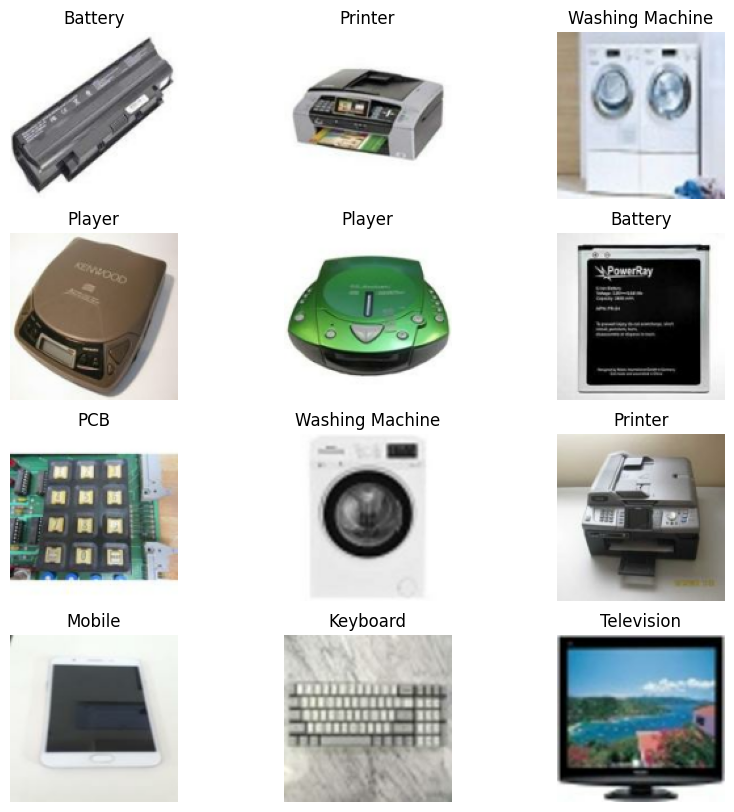

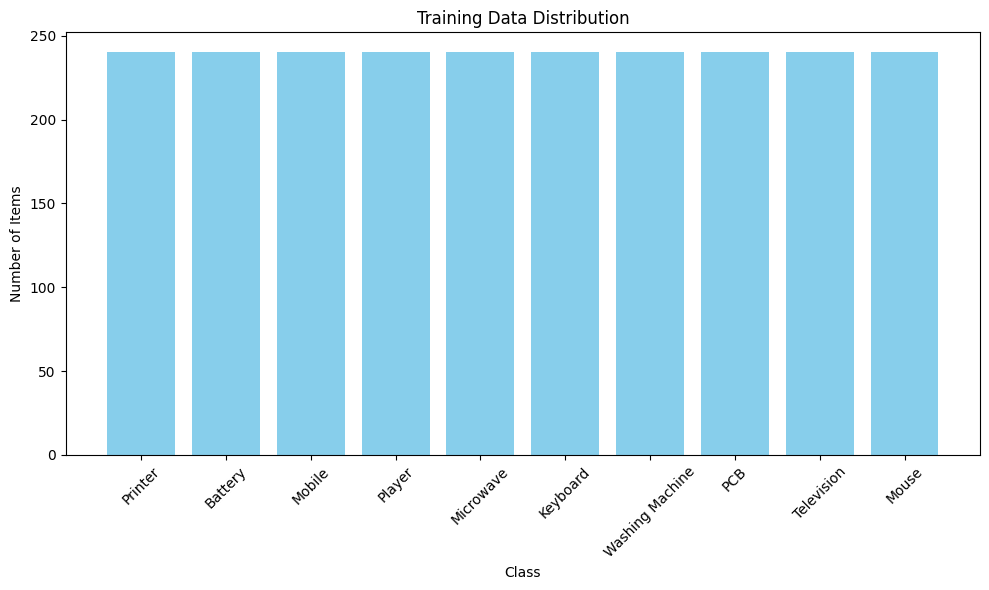

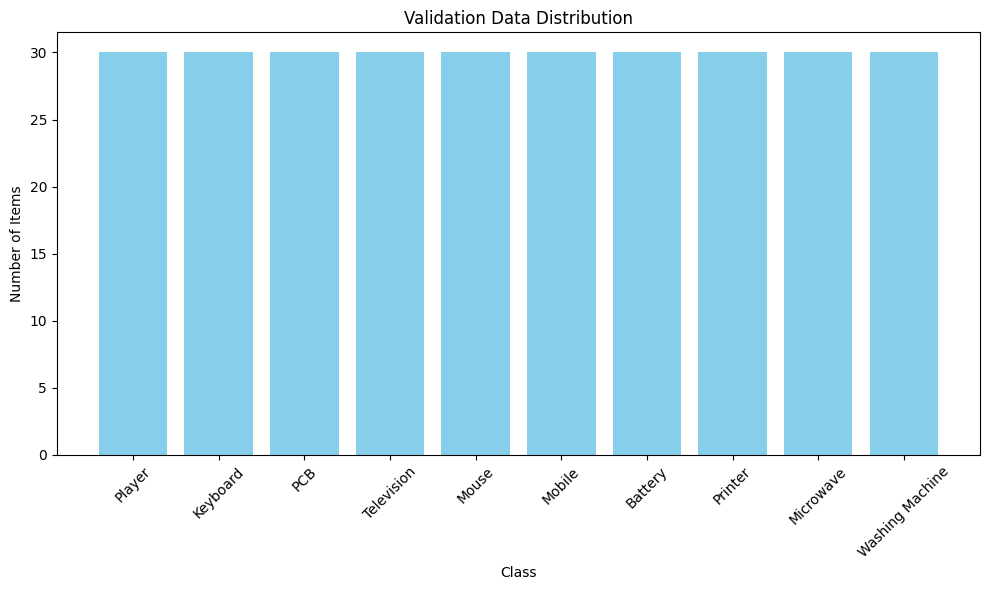

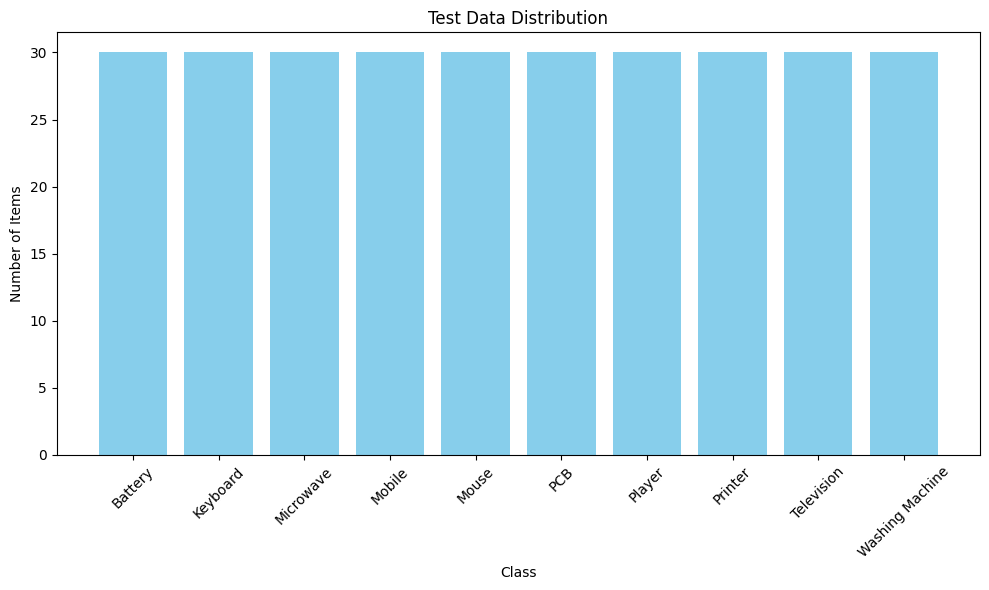

In [26]:
import tensorflow as tf  # Core TensorFlow library
import numpy as np
from tensorflow.keras import layers, models, optimizers, callbacks  # Layers, model creation, optimizers, and training callbacks

from tensorflow.keras.models import Sequential, load_model  # For sequential model architecture and loading saved models

from tensorflow.keras.applications import EfficientNetV2B0  # Pretrained EfficientNetV2B0 model for transfer learning

from tensorflow.keras.applications.efficientnet import preprocess_input  # Preprocessing function specific to EfficientNet

import numpy as np  # Numerical operations and array handling

import matplotlib.pyplot as plt  # Plotting graphs and images

import seaborn as sns  # Plotting graphs and images

from sklearn.metrics import confusion_matrix, classification_report

testpath=r"C:\Users\manth\Desktop\Final_E-waste_Generation_classification-main\modified-dataset\test"
trainpath=r"C:\Users\manth\Desktop\Final_E-waste_Generation_classification-main\modified-dataset\train"
validpath=r"C:\Users\manth\Desktop\Final_E-waste_Generation_classification-main\modified-dataset\val"

datavalid=tf.keras.utils.image_dataset_from_directory(validpath,shuffle=True,batch_size=32,image_size=(128,128),validation_split=False)
datatest=tf.keras.utils.image_dataset_from_directory(testpath,shuffle=False,image_size=(128,128),batch_size=32,validation_split=False)
datatrain=tf.keras.utils.image_dataset_from_directory(trainpath,shuffle=True,image_size=(128,128),batch_size=32,validation_split=False)

class_names = datatrain.class_names
print(len(class_names))
print(class_names)

# Set the size of the entire figure (width=10, height=10 inches)
plt.figure(figsize=(10, 10))

# Take one batch from the dataset and iterate over the images and labels
for images, labels in datatrain.take(1):
    # Display the first 12 images from the batch
    for i in range(12):
        # Create a 4x3 grid of subplots and select the (i+1)th position
        ax = plt.subplot(4, 3, i + 1)

        # Display the image; convert the tensor to a NumPy array and ensure correct type
        plt.imshow(images[i].numpy().astype("uint8"))

        # Set the title of the subplot to the class name of the image
        plt.title(class_names[labels[i]])

        # Remove axis ticks and labels for clarity
        plt.axis("off")

def plot_class_distribution(dataset, title="Class Distribution"):

    class_counts = {}  # Dictionary to hold the count of each class

    # Iterate through the batches in the dataset
    for images, labels in dataset:
        # Convert labels tensor to numpy array and loop through each label
        for label in labels.numpy():
            class_name = dataset.class_names[label]  # Get class name using label index
            # Increment the count for this class
            class_counts[class_name] = class_counts.get(class_name, 0) + 1


    # Prepare data for plotting
    class_names = list(class_counts.keys())  # List of class names
    counts = list(class_counts.values())     # Corresponding counts for each class

    # Create the bar plot
    plt.figure(figsize=(10, 6))  # Set the figure size
    plt.bar(class_names, counts, color='skyblue')  # Draw bars with class counts
    plt.xlabel("Class")  # X-axis label
    plt.ylabel("Number of Items")  # Y-axis label
    plt.title(title)  # Plot title
    plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
    plt.tight_layout()  # Adjust layout to prevent clipping
    plt.show()  # Display the plot
    
plot_class_distribution(datatrain, "Training Data Distribution")
plot_class_distribution(datavalid, "Validation Data Distribution")
plot_class_distribution(datatest, "Test Data Distribution")

In [27]:

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
  #  tf.keras.layers.RandomContrast(0.1),
    tf.keras.layers.RandomTranslation(0.1, 0.1)
    
])
base_model = tf.keras.applications.EfficientNetV2B0(
    input_shape=(128, 128, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = True
for layer in base_model.layers[:97]:
    layer.trainable = False

NUM_CLASSES = 10

model = tf.keras.Sequential([
   layers.Input(shape=(128, 128, 3)),
        data_augmentation,
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.2),
        layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        layers.Dropout(0.2),
        layers.Dense(NUM_CLASSES, activation='softmax')
])
    
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.000101),
              loss = tf.keras.losses.SparseCategoricalCrossentropy(), 
              metrics=['Accuracy'])

    
# Define an EarlyStopping callback to stop training when validation loss stops improving
early = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',            # Metric to monitor (validation loss here)
    patience=5,                   # Number of epochs to wait after last improvement before stopping
    restore_best_weights=True     # After stopping, restore the model weights from the epoch with the best val_loss
)

from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',     # Metric to monitor
    factor=0.1,             # Reduce learning rate by this factor
    patience=4,             # Number of epochs with no improvement before reducing
    verbose=1,              # Print messages
    min_lr=1e-6             # Lower bound on the learning rate
)

# Set the number of epochs to train the model
epochs = 20

# Train the model on the training dataset 'datatrain'
history = model.fit(
    datatrain,                      # Training data generator or dataset
    validation_data=datavalid,      # Validation data generator or dataset
    epochs=epochs,                  # Number of training epochs
    batch_size=100,                 # Number of samples per gradient update
    callbacks=[early, reduce_lr]               # List of callbacks to apply during training (e.g., early stopping)
)


Epoch 1/20
75/75 [==============================] - 53s 446ms/step - loss: 1.9501 - Accuracy: 0.3821 - val_loss: 1.2237 - val_Accuracy: 0.7733 - lr: 1.0100e-04
Epoch 2/20
75/75 [==============================] - 31s 415ms/step - loss: 0.9366 - Accuracy: 0.7738 - val_loss: 0.4988 - val_Accuracy: 0.8967 - lr: 1.0100e-04
Epoch 3/20
75/75 [==============================] - 31s 415ms/step - loss: 0.5106 - Accuracy: 0.8633 - val_loss: 0.3300 - val_Accuracy: 0.9333 - lr: 1.0100e-04
Epoch 4/20
75/75 [==============================] - 32s 428ms/step - loss: 0.3877 - Accuracy: 0.8933 - val_loss: 0.2652 - val_Accuracy: 0.9400 - lr: 1.0100e-04
Epoch 5/20
75/75 [==============================] - 32s 426ms/step - loss: 0.3162 - Accuracy: 0.9146 - val_loss: 0.2300 - val_Accuracy: 0.9433 - lr: 1.0100e-04
Epoch 6/20
75/75 [==============================] - 31s 415ms/step - loss: 0.2625 - Accuracy: 0.9375 - val_loss: 0.2003 - val_Accuracy: 0.9567 - lr: 1.0100e-04
Epoch 7/20
75/75 [======================

In [28]:
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_2 (Sequential)   (None, 128, 128, 3)       0         
                                                                 
 efficientnetv2-b0 (Function  (None, 4, 4, 1280)       5919312   
 al)                                                             
                                                                 
 global_average_pooling2d_1   (None, 1280)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dropout_2 (Dropout)         (None, 1280)              0         
                                                                 
 dense_2 (Dense)             (None, 256)               327936    
                                                                 
 dropout_3 (Dropout)         (None, 256)              

In [29]:
base_model.summary() # Print the architecture summary of the base model

Model: "efficientnetv2-b0"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_3 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 rescaling_1 (Rescaling)        (None, 128, 128, 3)  0           ['input_3[0][0]']                
                                                                                                  
 normalization_1 (Normalization  (None, 128, 128, 3)  0          ['rescaling_1[0][0]']            
 )                                                                                                
                                                                                  

In [30]:
### Plotting Training and Validation Accuracy and Loss Over Epochs

acc = history.history['Accuracy']           # Training accuracy
val_acc = history.history['val_Accuracy']   # Validation accuracy
loss = history.history['loss']              # Training loss
val_loss = history.history['val_loss']      # Validation loss

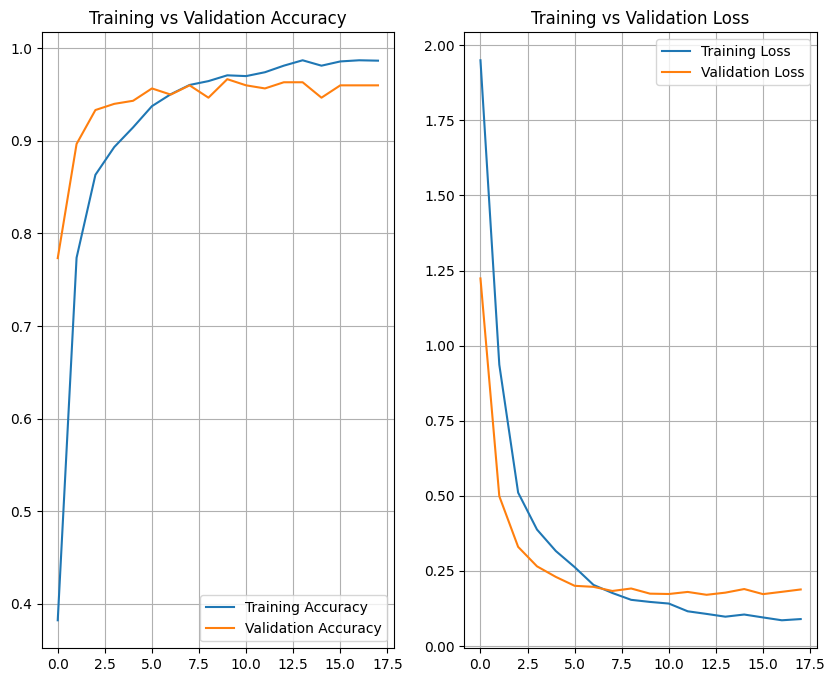

In [31]:
epochs_range = range(len(acc))              # X-axis range based on number of epochs

plt.figure(figsize=(10, 8))                 # Set overall figure size

plt.subplot(1, 2, 1)                        # 1 row, 2 columns, position 1
plt.plot(epochs_range, acc, label='Training Accuracy')       # Plot training accuracy
plt.plot(epochs_range, val_acc, label='Validation Accuracy') # Plot validation accuracy
plt.legend(loc='lower right')              # Show legend at lower right
plt.title('Training vs Validation Accuracy') # Set title for accuracy plot
plt.grid(True)

plt.subplot(1, 2, 2)                        # 1 row, 2 columns, position 2
plt.plot(epochs_range, loss, label='Training Loss')          # Plot training loss
plt.plot(epochs_range, val_loss, label='Validation Loss')    # Plot validation loss
plt.legend(loc='upper right')              # Show legend at upper right
plt.title('Training vs Validation Loss')    # Set title for loss plot
plt.grid(True)

plt.show()                                  # Display the plots


In [32]:
loss, accuracy = model.evaluate(datatest)
print(f'Test accuracy is{accuracy:.4f}, Test loss is {loss:.4f}')

10/10 [==============================] - 1s 123ms/step - loss: 0.1790 - Accuracy: 0.9500
Test accuracy is0.9500, Test loss is 0.1790


In [34]:
import json
from pathlib import Path

ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

model.save(ARTIFACT_DIR / "ewaste_classifier.keras")
with open(ARTIFACT_DIR / "class_names.json", "w", encoding="utf-8") as f:
    json.dump(class_names, f, indent=2)

print("Saved artifacts in ./artifacts")

Saved artifacts in ./artifacts


In [35]:
import os
from pathlib import Path
import json

print("Notebook CWD:", os.getcwd())

ARTIFACT_DIR = Path("artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

model_path = ARTIFACT_DIR / "ewaste_classifier.keras"
model.save(model_path)

with open(ARTIFACT_DIR / "class_names.json", "w", encoding="utf-8") as f:
    json.dump(class_names, f, indent=2)

print("Saved model to:", model_path.resolve())
print("Exists?", model_path.exists())
print("Artifacts:", [p.name for p in ARTIFACT_DIR.iterdir()])

Notebook CWD: c:\Users\manth\Desktop\Final_E-waste_Generation_classification-main
Saved model to: C:\Users\manth\Desktop\Final_E-waste_Generation_classification-main\artifacts\ewaste_classifier.keras
Exists? True
Artifacts: ['class_names.json', 'ewaste_classifier.keras']
